In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ibicus.debias import (
    QuantileMapping,
    ISIMIP,
    QuantileDeltaMapping,
    ECDFM,
    ScaledDistributionMapping,
    CDFt,
)
import xarray as xr
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#################
### VARIABLES ###
#################
reanalysis_hindcast_netcdf_path = "NetCDF_data/reanalysis_hindcast_copernicus.nc"
reanalysis_validation_netcdf_path = "NetCDF_data/reanalysis_validation_copernicus.nc"
projections_hindcast_netcdf_path = "NetCDF_data/ECMWF_hindcast_projections.nc"
projections_validation_netcdf_path = "NetCDF_data/ECMWF_validation_projections.nc"

# Test t2m (average temperature).
# mn2t24 (min. average temperature) or mx2t24(max. average temperature) can be analyzed
# if monthly data for these is available in all four NetCDF files above.
VARIABLE = "t2m"

# Variable for the debiaser: "tas", "tasmin", "tasmax", based on
# respectively mean, min, and max temp data
IBICUS_VAR = "tas"

# Gridcell location of Qahbunah in the data
QAHBUNAH_X = 7
QAHBUNAH_Y = 0


In [4]:
#################
### LOAD DATA ###
#################
reanalysis_hindcast_ds = xr.open_dataset(reanalysis_hindcast_netcdf_path)
reanalysis_validation_ds = xr.open_dataset(reanalysis_validation_netcdf_path)
projections_hindcast_ds = xr.open_dataset(projections_hindcast_netcdf_path)
projections_validation_ds = xr.open_dataset(projections_validation_netcdf_path)

# Collapse ensemble member dimension in projection data
projections_hindcast_ds = projections_hindcast_ds.mean(dim="number")
projections_validation_ds = projections_validation_ds.mean(dim="number")

# Interpolate reanalysis_ds to the (courser) dimension of projections_ds
reanalysis_hindcast_ds = reanalysis_hindcast_ds.interp_like(projections_hindcast_ds)
reanalysis_validation_ds = reanalysis_validation_ds.interp_like(projections_validation_ds)

# Convert to numpy arrays to work with ibicus
# (time, lat, lon)
reanalysis_hindcast_np = reanalysis_hindcast_ds[VARIABLE].to_numpy()
reanalysis_validation_np = reanalysis_validation_ds[VARIABLE].to_numpy()
# (leadtime, time, lat, lon)
projections_hindcast_np = projections_hindcast_ds[VARIABLE].to_numpy()
projections_validation_np = projections_validation_ds[VARIABLE].to_numpy()


In [5]:
#######################
### BIAS ADJUSTMENT ###
#######################
def apply_debiaser(debiaser):
    output = np.empty_like(projections_validation_np)
    for i, _ in enumerate(projections_hindcast_ds.forecastMonth):
        output[i] = debiaser.apply(
            reanalysis_hindcast_np,
            projections_hindcast_np[i],
            projections_validation_np[i],
            time_obs=reanalysis_hindcast_ds.time.values,
            time_cm_hist=projections_hindcast_ds.time.values,
            time_cm_future=projections_validation_ds.time.values,
        )
    return output


# Quartile Mapping adjustment
QM_debiaser = QuantileMapping.from_variable(IBICUS_VAR)
QM_val = apply_debiaser(QM_debiaser)


# ISIMIP
ISIMIP_debiaser = ISIMIP.from_variable(IBICUS_VAR)
ISIMIP_debiaser.detrending = False
ISIMIP_val = apply_debiaser(ISIMIP_debiaser)

# QuantileDeltaMapping
QDM_debiaser = QuantileDeltaMapping.from_variable(IBICUS_VAR)
QDM_val = apply_debiaser(QDM_debiaser)

ECDFM
ECDFM_debiaser = ECDFM.from_variable(IBICUS_VAR)
ECDFM_val = apply_debiaser(ECDFM_debiaser)

# # Scaled Distribution Mapping
SDM_debiaser = ScaledDistributionMapping.from_variable(IBICUS_VAR)
SDM_val = apply_debiaser(SDM_debiaser)

# # CDFt (Cumulative Distribution Function transform)
CDFt_debiaser = CDFt.from_variable(IBICUS_VAR)
CDFt_val = apply_debiaser(CDFt_debiaser)

100%|██████████| 130/130 [00:04<00:00, 26.21it/s]


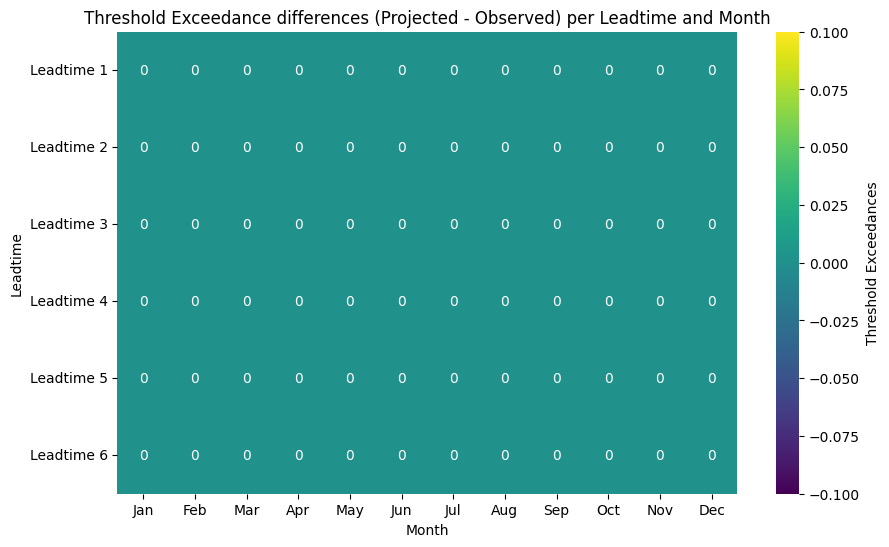

In [ ]:
######################
### ERROR ANALYSIS ###
######################


def calculate_treshold_exceedances_list(df, thresholds_list):
    threshold_map = np.full_like(df, False, dtype=bool)  # Fill with False
    for i in range(df.shape[1]):
        for entry in thresholds_list:
            if (i + 1) % 12 == entry[0]:
                # Assign the boolean mask to the corresponding frame
                threshold_map[:, i, :, :] = (df[:, i] < entry[1]) | (df[:, i] > entry[2])
    data = np.zeros((6, 12))
    for i, _ in enumerate(threshold_map[:, 0, 0, 0]):
        for j, _ in enumerate(threshold_map[0, :, 0, 0]):
            data[i, j % 12] = (
                data[i, j % 12] + threshold_map[i, j, QAHBUNAH_Y, QAHBUNAH_X]
            )
    return data


def calculate_treshold_exceedances_list_obs(df, thresholds_list):
    threshold_map = np.full_like(df, False, dtype=bool)  # Fill with False
    # obs_df shape: (time, lat, lon)
    for i in range(df.shape[0]):
        for entry in thresholds_list:
            if (i + 1) % 12 == entry[0]:
                # Assign the boolean mask to the corresponding frame
                threshold_map[i] = (df[i] < entry[1]) | (df[i] > entry[2])
    data = np.zeros(12)
    for j in range(df.shape[0]):
        data[j % 12] = data[j % 12] + threshold_map[j, QAHBUNAH_Y, QAHBUNAH_X]
    return data


def calculate_threshold_exceedances_per_leadtime_month(df, threshold):
    threshold_map = (df < threshold[0]) | (df > threshold[1])
    data = np.zeros((6, 12))
    for i, _ in enumerate(threshold_map[:, 0, 0, 0]):
        for j, _ in enumerate(threshold_map[0, :, 0, 0]):
            data[i, j % 12] = data[i, j % 12] + threshold_map[i, j, 1, 3]
    return data


def calculate_threshold_exceedances_per_month(obs_df, threshold):
    threshold_map = (obs_df > threshold[0]) & (obs_df < threshold[1])
    # obs_df shape: (time, lat, lon)
    data = np.zeros(12)
    for i in range(obs_df.shape[0]):
        data[i % 12] += threshold_map[i, 1, 3]
    return data


def plot_heatmap(data, title, colorbar_label, decimals=1):
    df = pd.DataFrame(
        data,
        columns=[
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ],
    )
    df.index = [f"Leadtime {i + 1}" for i in range(data.shape[0])]

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df,
        annot=True,
        fmt=f".{decimals}f",
        cmap="viridis",
        cbar_kws={"label": colorbar_label},
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Leadtime")
    plt.show()


sample_threshold = [294, 313]

# (month, low threshold, high treshold)
thresholds_rice = [
    (5, 13, 35),
    (6, 13, 35),
    (7, 20, 35),
    (8, 20, 35),
    (9, 20, 35),
]
QDM_val_C = QDM_val - 273.15
reanalysis_validation_np_C = reanalysis_validation_np - 273.15
QDM_threshold = calculate_treshold_exceedances_list(QDM_val_C, thresholds_rice)
# raw_threshold = calculate_threshold_exceedances_per_leadtime_month(
#     projections_validation_np, sample_threshold
# )

# QDM_threshold = calculate_threshold_exceedances_per_leadtime_month(QDM_val, sample_threshold)
obs_threshold = calculate_treshold_exceedances_list_obs(
    reanalysis_validation_np_C, thresholds_rice
)
diff_threshold = QDM_threshold - obs_threshold

plot_heatmap(
    diff_threshold,
    "Threshold Exceedance differences (Projected - Observed) per Leadtime and Month",
    "Threshold Exceedances",
    0,
)


In [ ]:
def plot_heatmap(data, title, colorbar_label, decimals=1):
    df = pd.DataFrame(
        data,
        columns=[
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ],
    )
    df.index = [f"Leadtime {i + 1}" for i in range(data.shape[0])]

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df,
        annot=True,
        fmt=f".{decimals}f",
        cmap="viridis",
        cbar_kws={"label": colorbar_label},
        vmin=0,
        vmax=4.1,
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Leadtime")
    plt.show()


## MAE per leadtime per month
def calculate_MAE_per_leadtime_month(df):
    AE_map = abs(df - reanalysis_validation_np)
    data = np.zeros((6, 12))
    for i, _ in enumerate(AE_map[:, 0, 0, 0]):
        for j, _ in enumerate(AE_map[0, :, 0, 0]):
            data[i, j % 12] = data[i, j % 12] + AE_map[i, j, QAHBUNAH_Y, QAHBUNAH_X]
    # Since means can be summed over multiple years, divide by number of years in the data
    data = data / (reanalysis_validation_np.shape[0] / 12)
    return data


MAE_leadtime_month = calculate_MAE_per_leadtime_month(projections_validation_np)
plot_heatmap(MAE_leadtime_month, "Raw AE per Leadtime and Month for Qabunah", "AE (K)")

MAE_leadtime_month = calculate_MAE_per_leadtime_month(QM_val)
print(f"QM Error sum: {MAE_leadtime_month.sum()}")
plot_heatmap(MAE_leadtime_month, "QM AE per Leadtime and Month for Qabunah", "AE (K)")

# MAE_leadtime_month = calculate_MAE_per_leadtime_month(ISIMIP_val)
# plot_heatmap(
#     MAE_leadtime_month,
#     "ISIMIP (no detrending) AE per Leadtime and Month for Qabunah",
#     "AE (K)",
# )

MAE_leadtime_month = calculate_MAE_per_leadtime_month(QDM_val)
print(f"QDM Error sum: {MAE_leadtime_month.sum()}")
plot_heatmap(MAE_leadtime_month, "QDM AE per Leadtime and Month for Qabunah", "AE (K)")

# MAE_leadtime_month = calculate_MAE_per_leadtime_month(ECDFM_val)
# plot_heatmap(MAE_leadtime_month, "ECDFM AE per Leadtime and Month for Qabunah", "AE (K)")

# MAE_leadtime_month = calculate_MAE_per_leadtime_month(SDM_val)
# plot_heatmap(MAE_leadtime_month, "SDM AE per Leadtime and Month for Qabunah", "AE (K)")

# MAE_leadtime_month = calculate_MAE_per_leadtime_month(CDFt_val)
# plot_heatmap(MAE_leadtime_month, "CDFt AE per Leadtime and Month for Qabunah", "AE (K)")

In [ ]:
## Spatial MAE for all leadtimes


def plot_spatial_mae(data, suptitle):
    fig, axes = plt.subplots(
        2, 3, figsize=(25, 10), subplot_kw={"projection": ccrs.PlateCarree()}
    )
    # Set extent to just Egypt (approximate bounds)
    # for ax in axes.flat:
    #     ax.set_extent([24, 36, 21, 32], crs=ccrs.PlateCarree())
    forecast_months = range(1, 7)
    fig.suptitle(suptitle, fontsize=30, fontweight="bold")
    for i, forecast_month in enumerate(forecast_months):
        ax = axes[i // 3, i % 3]
        cbar = (
            data.sel(forecastMonth=forecast_month)
            .plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                vmin=0,
                vmax=5,
            )
            .colorbar
        )
        cbar.ax.tick_params(labelsize=16)
        cbar.ax.set_ylabel("")
        ax.set_title(f"Lead-time (months): {forecast_month}", fontsize=24)
        ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black")
        ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    plt.show()


def abs_error_map(debiased_val):
    abs_error = abs(debiased_val - reanalysis_validation_np)
    abs_error_map = abs_error.mean(axis=(1))
    abs_error_map = xr.DataArray(
        abs_error_map,
        dims=("forecastMonth", "latitude", "longitude"),
        coords={
            "forecastMonth": projections_validation_ds.forecastMonth,
            "latitude": projections_validation_ds.latitude,
            "longitude": projections_validation_ds.longitude,
        },
        name=VARIABLE,
    )
    return abs_error_map


raw_abs_error_map = abs_error_map(projections_validation_np)
QM_abs_error_map = abs_error_map(QM_val)
ISIMIP_abs_error_map = abs_error_map(ISIMIP_val)
QDM_abs_error_map = abs_error_map(QDM_val)

plot_spatial_mae(raw_abs_error_map, "Raw MAE")
plot_spatial_mae(QM_abs_error_map, "QM Bias corrected MAE")
plot_spatial_mae(ISIMIP_abs_error_map, "ISIMIP Bias corrected MAE")
plot_spatial_mae(QDM_abs_error_map, "QDM Bias corrected MAE")